# Actividad Aplicacion de Algoritmos Geneticos

**Ejercicio del problema del viajero**


COnsiste en resolver el ejercicio planteado para la semana 7 basado en el material propiesto y la implementacion de la libreria PyGad mediante la implementacion de un AG para encontrar la ruta aproximada

**Objetivo**

Diseñar e implementar un AG para encontrar una solucion aproximada al problema del viajante, minimizando la distancia totoal recorrida

In [6]:
""""Librerias base a utilizar"""


import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pygad 

print("Librerias instaladas y funcionando ")

Librerias instaladas y funcionando 


# Definicion del problema planteado

*Se usara el conjunto de las ciuidades de ejemplo propuestas basado en el enunciado* ´n=5' *representado con las coordenadas* '(x,y)' donde en el proceso del codigo se generarra el conjunto de las ciduidades mas grandes alearoriamente

In [7]:
"""defincion de las ciudades del ejemplo del enunciado n = 5 """ 

cities = np.array([
    (0 , 0), 
    (2 , 3),
    (5 , 4), 
    (7 , 1),
    (8 , 5),
], dtype=float) 

num_cities = len(cities)


"""Funcion para calcular la distancua entre dos ciuidades"""

def build_distance_matrix(coords):

    n = len(coords)
    D = np.zeros((n, n))
    for i in range(n):
        for j in range(n):
            D[i, j] = np.linalg.norm(coords[i] - coords[j])
    return D

distance_matrix = build_distance_matrix(cities)
print("Matriz de distancias:\n", np.round(distance_matrix, 2))


Matriz de distancias:
 [[0.   3.61 6.4  7.07 9.43]
 [3.61 0.   3.16 5.39 6.32]
 [6.4  3.16 0.   3.61 3.16]
 [7.07 5.39 3.61 0.   4.12]
 [9.43 6.32 3.16 4.12 0.  ]]


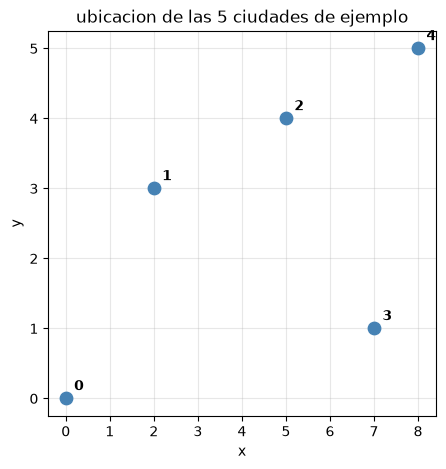

In [3]:
"""funcion para mapear las ciudades en un grafico de dispersion"""

def plot_cities(coords, title="Ciudades"):
    plt.figure(figsize=(5, 5))
    plt.scatter(coords[:, 0], coords[:, 1], c="steelblue", s=80, zorder=3)
    for idx, (x, y) in enumerate(coords):
        plt.annotate(str(idx), (x, y), textcoords="offset points",
                     xytext=(6, 6), fontsize=10, fontweight="bold")
    plt.title(title)
    plt.xlabel("x")
    plt.ylabel("y")
    plt.grid(alpha=0.3)
    plt.show()


plot_cities(cities, title=f"ubicacion de las {num_cities} ciudades de ejemplo")

# Funcion para calcular distancia total de la ruta / funcion de aptitud (Fitness)

*La funcion recibe una permutacion (Soluction), la cual calcula la longitud total del recorrido incluyendo el regreso a la ciudad inicial, usando la matriz de distancia u retorna* ´1 / distancia_total' con valor de aptitud a maximizar

In [8]:
def route_length(route, D):
    """distancia total de una ruta cerrada, regresando al punto de partida"""
    total = 0.0
    n = len(route)
    for i in range(n):
        total += D[route[i], route[(i + 1) % n]]
    return total

def make_fitness_func(D):
    """Crea una funcion de aptitud enlazada a una matriz de distancias D"""
    def fitness_func(ga_instance, solution, solution_idx):
        route = np.array(solution, dtype=int)
        total_distance = route_length(route, D)
        return 1.0 / total_distance if total_distance > 0 else float("inf")
    return fitness_func


fitness_func = make_fitness_func(distance_matrix)

# Configuracion y ejecucion de Algoritmo Genetico


*configurando la instancia de pygad.GA Con los parametros sugeridos en el enunciado. seleccion por torneo, cruce d eun punto y mutacion aleatoria*

Un punto importante para el TSP: como cada gen representa el índice de una ciudad y **no se pueden repetir**, se usa:

- `gene_type=int` — los genes son enteros (indices de ciudades)
- `gene_space=range(num_cities)` — el rango valido de indices
- `allow_duplicate_genes=False` — evita que una ciudad aparezca dos veces en la misma ruta, lo que mantiene la validez de la permutacion tras el cruce y la mutacion

In [9]:
def run_tsp_ga(D, num_cities, crossover_type="single_point",
                num_generations=500, num_parents_mating=5, sol_per_pop=10,
                mutation_percent_genes=10, random_seed=None):
    """Configura y ejecuta un AG con PyGAD para resolver el TSP

    Retorna un diccionario con la mejor ruta, la distancia, el tiempo de
    ejecución y la instancia de GA (es util para graficar la evolucion del
    fitness)
    """
    fitness = make_fitness_func(D)

    ga_instance = pygad.GA(
        num_generations=num_generations,
        num_parents_mating=num_parents_mating,
        fitness_func=fitness,
        sol_per_pop=sol_per_pop,
        num_genes=num_cities,
        gene_type=int,
        gene_space=range(num_cities),
        allow_duplicate_genes=False,
        init_range_low=0,
        init_range_high=num_cities - 1,
        parent_selection_type="tournament",
        keep_parents=2,
        crossover_type=crossover_type,
        mutation_type="random",
        mutation_percent_genes=mutation_percent_genes,
        random_seed=random_seed,
        suppress_warnings=True,
    )

    start = time.perf_counter()
    ga_instance.run()
    elapsed = time.perf_counter() - start

    solution, solution_fitness, _ = ga_instance.best_solution()
    best_route = np.array(solution, dtype=int)
    best_distance = route_length(best_route, D)

    return {
        "route": best_route,
        "distance": best_distance,
        "time": elapsed,
        "ga_instance": ga_instance,
        "crossover_type": crossover_type,
    }


baseline = run_tsp_ga(distance_matrix, num_cities, crossover_type="single_point",
                       random_seed=42)

print("Mejor ruta encontrada:", baseline["route"])
print(f"Distancia total: {baseline['distance']:.4f}")
print(f"Tiempo de ejecución: {baseline['time']:.4f} s")

Mejor ruta encontrada: [4 3 0 1 2]
Distancia total: 21.1243
Tiempo de ejecución: 0.3495 s


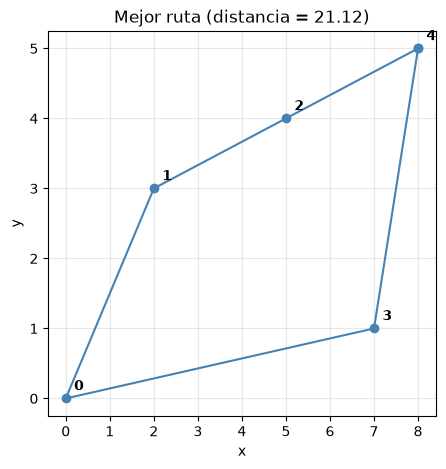

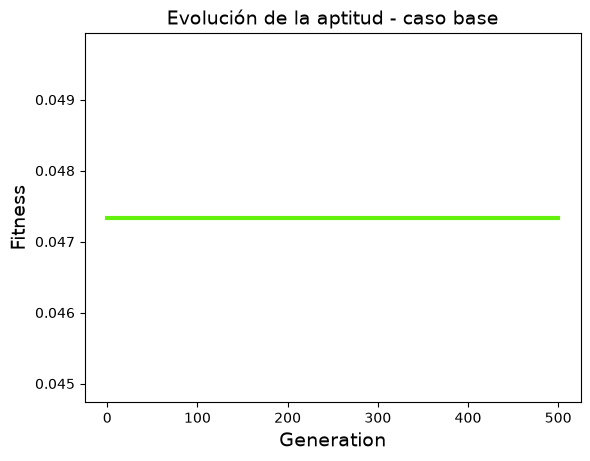

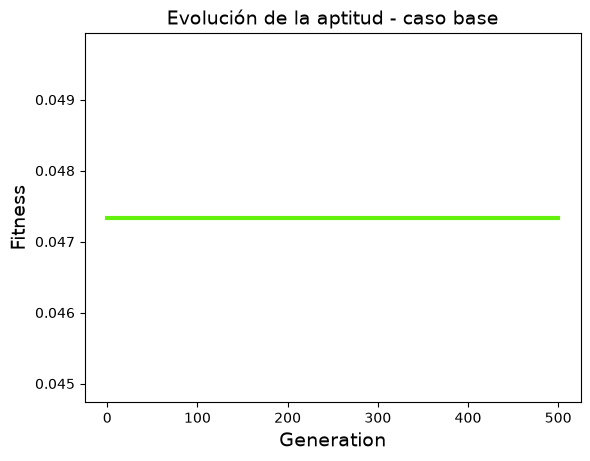

In [10]:
"""Funcion para hayar la mejor ruta y graficarla"""

def plot_route(coords, route, title="Mejor ruta encontrada"):
    ordered = coords[np.append(route, route[0])]
    plt.figure(figsize=(5, 5))
    plt.plot(ordered[:, 0], ordered[:, 1], "o-", c="steelblue", zorder=2)
    for idx, (x, y) in enumerate(coords):
        plt.annotate(str(idx), (x, y), textcoords="offset points",
                     xytext=(6, 6), fontsize=10, fontweight="bold")
    plt.title(title)
    plt.xlabel("x")
    plt.ylabel("y")
    plt.grid(alpha=0.3)
    plt.show()


plot_route(cities, baseline["route"],
           title=f"Mejor ruta (distancia = {baseline['distance']:.2f})")

# Evolucion del fitness a lo largo de las generaciones
baseline["ga_instance"].plot_fitness(title="Evolución de la aptitud - caso base")